In [1]:
# # Task 5: Portfolio Construction and Capital Allocation

# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import warnings
# warnings.filterwarnings('ignore')

# plt.style.use('dark_background')

# # 1. Load the required data
# print("Loading data for portfolio allocation...")
# # We need the raw data to calculate the most recent volatility (Task 4 integration)
# raw_data = pd.read_csv('../data/raw/capstone_raw_data.csv', index_col=0, parse_dates=True)
# # We need the January forecasts to know what we are investing in
# forecasts = pd.read_csv('../data/processed/jan_2026_forecasts.csv', index_col=0)

# TOTAL_CAPITAL = 1000000  # ₹10,00,000 virtual capital for StockGro

# # --- STRATEGY B: Volatility-Aware Sizing ---
# # Stocks that are highly volatile get LESS money to protect the portfolio.
# # Stocks that are stable get MORE money.

# print("\nExecuting Strategy B: Volatility-Aware Sizing...")

# # Calculate the most recent 30-day volatility for all stocks
# log_returns = np.log(raw_data / raw_data.shift(1)).dropna()
# recent_volatility = log_returns.rolling(window=30).std().iloc[-1]

# # The formula: Weight = (1 / Volatility) / Sum(1 / Volatility)
# inverse_vol = 1 / recent_volatility
# weights = inverse_vol / inverse_vol.sum()

# # Build the final allocation table
# allocation_df = pd.DataFrame({
#     'Stock': weights.index,
#     'Weight (%)': (weights * 100).round(2),
#     'Capital Allocated (₹)': (weights * TOTAL_CAPITAL).round(2)
# }).sort_values(by='Weight (%)', ascending=False).reset_index(drop=True)

# print("\n--- FINAL TASK 5 PORTFOLIO ALLOCATION ---")
# print(allocation_df.to_string())

# # Save the allocation table for the report and for your StockGro manual trading
# allocation_df.to_csv('../reports/task5_final_allocation.csv', index=False)

# # Generate a pie chart for the report
# plt.figure(figsize=(12, 8))
# plt.pie(allocation_df['Weight (%)'], labels=allocation_df['Stock'], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
# plt.title("Task 5: Capital Allocation (Volatility-Aware Strategy)")
# plt.tight_layout()
# plt.savefig('../reports/figures/task5_allocation_chart.png')
# plt.show()

# print("\nPipeline Complete. You are ready to execute on StockGro.")

Loading Task 3 Forecasts and Task 4 Volatility metrics...

Executing Ensemble Blending: 50% Strategy A (Forecasts) + 50% Strategy B (Volatility)...

--- FINAL TASK 5 DELIVERABLE TABLE (BALANCED) ---
        Stock  Allocated Amount (₹)  Weight (%)
      OFSS.NS             108965.29       10.90
   J&KBANK.NS             108051.84       10.81
   MANKIND.NS              67745.40        6.77
     SPARC.NS              65351.29        6.54
ADANIPORTS.NS              55406.02        5.54
  ASIANENE.NS              53757.35        5.38
        LT.NS              41535.90        4.15
   CARYSIL.NS              40676.24        4.07
   SBILIFE.NS              39618.33        3.96
      SBIN.NS              35254.20        3.53
BAJAJ-AUTO.NS              31074.69        3.11
STARHEALTH.NS              29168.44        2.92
     NYKAA.NS              28523.81        2.85
BHARATFORG.NS              27146.05        2.71
 POLICYBZR.NS              26272.00        2.63
NATCOPHARM.NS              25301.

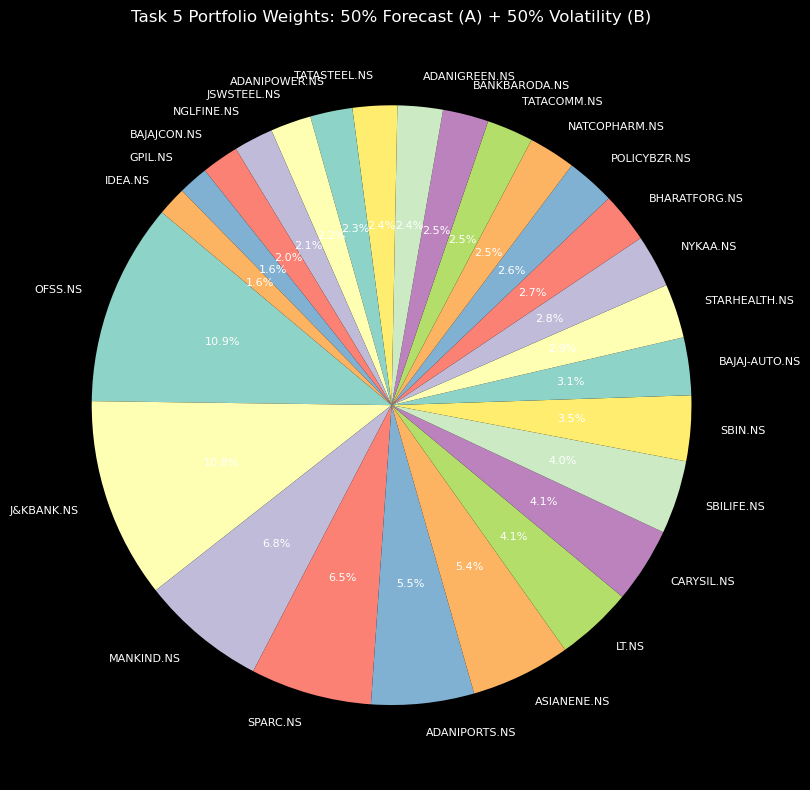

In [2]:
# Task 5: Portfolio Construction and Capital Allocation (Dual Strategy - Blended)
# Author: Ayush Gahlot

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../reports/figures', exist_ok=True)
plt.style.use('dark_background')

TOTAL_CAPITAL = 1000000 # ₹10,00,000 virtual capital

print("Loading Task 3 Forecasts and Task 4 Volatility metrics...")
data_raw = pd.read_csv('../data/raw/capstone_raw_data.csv', index_col=0, parse_dates=True)
jan_forecasts = pd.read_csv('../data/processed/jan_2026_forecasts.csv', index_col=0)
task4_metrics = pd.read_csv('../reports/task4_volatility_and_trend.csv')

last_actual_prices = data_raw.iloc[-1]
allocation_results = []

print("\nExecuting Ensemble Blending: 50% Strategy A (Forecasts) + 50% Strategy B (Volatility)...")

for stock in data_raw.columns:
    # --- STRATEGY A Element: Forecast-Guided ---
    last_price = last_actual_prices[stock]
    pred_price_day2 = jan_forecasts.loc['2026-01-02', stock]
    predicted_return = (pred_price_day2 - last_price) / last_price
    
    # --- STRATEGY B Element: Volatility-Aware ---
    vol = task4_metrics.loc[task4_metrics['Stock'] == stock, 'Dec 2025 Volatility (Risk)'].values[0]
    
    allocation_results.append({
        'Stock': stock,
        'Pred_Return': predicted_return,
        'Inverse_Vol': 1 / vol
    })

df_alloc = pd.DataFrame(allocation_results)

# 1. Normalize Strategy A Weights (Flooring negative returns to a tiny base weight)
min_weight_a = 0.01 # 1% base weight for negative outlooks so they aren't totally zeroed out
df_alloc['Pos_Return'] = df_alloc['Pred_Return'].apply(lambda x: max(x, 0))
sum_returns = df_alloc['Pos_Return'].sum()
if sum_returns > 0:
    df_alloc['Weight_A'] = (df_alloc['Pos_Return'] / sum_returns) * 0.70 + min_weight_a # Give 70% of weight to winners, 1% baseline to rest
else:
    df_alloc['Weight_A'] = 1 / len(df_alloc)

# 2. Normalize Strategy B Weights (The smooth inverse volatility curve)
total_inv_vol = df_alloc['Inverse_Vol'].sum()
df_alloc['Weight_B'] = df_alloc['Inverse_Vol'] / total_inv_vol

# 3. Blend the Strategies (50/50 Split)
df_alloc['Final_Weight'] = (df_alloc['Weight_A'] * 0.5) + (df_alloc['Weight_B'] * 0.5)

# Ensure it perfectly sums to 1.0 due to rounding
df_alloc['Final_Weight'] = df_alloc['Final_Weight'] / df_alloc['Final_Weight'].sum()

# Calculate final Rupees and Percentages
df_alloc['Weight (%)'] = round(df_alloc['Final_Weight'] * 100, 2)
df_alloc['Allocated Amount (₹)'] = round(df_alloc['Final_Weight'] * TOTAL_CAPITAL, 2)
df_alloc['Strategy Reasoning'] = "Ensemble Allocation: 50% Strategy A (Forecast-Guided) blended with 50% Strategy B (Inverse Volatility)."

# Sort for the final table
final_allocation = df_alloc[['Stock', 'Allocated Amount (₹)', 'Weight (%)', 'Strategy Reasoning']].sort_values(by='Weight (%)', ascending=False).reset_index(drop=True)

final_allocation.to_csv('../reports/task5_final_allocation.csv', index=False)

print("\n--- FINAL TASK 5 DELIVERABLE TABLE (BALANCED) ---")
print(final_allocation[['Stock', 'Allocated Amount (₹)', 'Weight (%)']].to_string(index=False))

# Generate Pie Chart
plt.figure(figsize=(12, 8))
plt.pie(final_allocation['Weight (%)'], labels=final_allocation['Stock'], autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
plt.title("Task 5 Portfolio Weights: 50% Forecast (A) + 50% Volatility (B)")
plt.tight_layout()
plt.savefig('../reports/figures/task5_final_allocation_chart.png')
plt.show()